In [11]:
import kagglehub
path = kagglehub.competition_download('ieee-fraud-detection')

In [12]:
import pandas as pd

train_transaction = pd.read_csv(f'{path}/train_transaction.csv', index_col='TransactionID')
train_identity = pd.read_csv(f'{path}/train_identity.csv', index_col='TransactionID')

train = train_transaction.join(train_identity, how='left')

print(train_transaction.shape, train_identity.shape, train.shape)
train.head()

(590540, 393) (144233, 40) (590540, 433)


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
TransactionID,,,,,,,,,,,,,,,,,,,,,
2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [13]:
counts = train['isFraud'].value_counts().reindex([0, 1])
pct = counts / counts.sum() * 100

summary = pd.DataFrame({'count': counts, 'percent': pct.round(3)})
summary.index = ['legitimate (0)', 'fraud (1)']
print(summary)
print(f"\nfraud rate      : {pct.iloc[1]:.3f}%")
print(f"imbalance ratio : {counts.iloc[0] / counts.iloc[1]:.1f} : 1")
print(f"missing labels  : {train['isFraud'].isna().sum()}")

                 count  percent
legitimate (0)  569877   96.501
fraud (1)        20663    3.499

fraud rate      : 3.499%
imbalance ratio : 27.6 : 1
missing labels  : 0


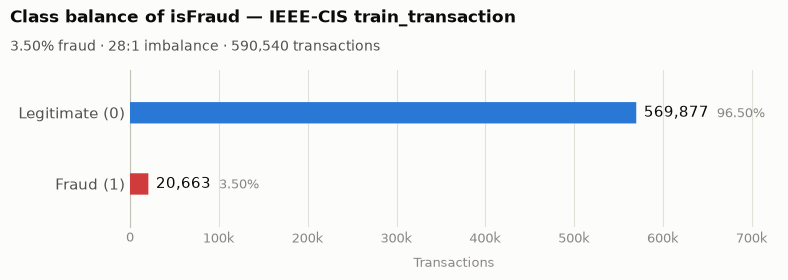

In [14]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

SURFACE, INK, INK2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, RED = '#2a78d6', '#d03b3b'


def rbar(ax, y0, width, height, color, r_frac=0.35):
    """Horizontal bar, rounded at the data end, square at the baseline."""
    r = min(height * r_frac, width)
    yb, yt = y0 - height / 2, y0 + height / 2
    verts = [(0, yb), (width - r, yb), (width, yb), (width, y0), (width, yt),
             (width - r, yt), (0, yt), (0, yb)]
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3, Path.CURVE3,
             Path.CURVE3, Path.LINETO, Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts, codes), fc=color, ec='none', zorder=3))


fig, ax = plt.subplots(figsize=(8, 2.9), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for i, (c, col) in enumerate(zip(counts, [BLUE, RED])):
    rbar(ax, i, c, 0.3, col)
    t = ax.text(c + counts.max() * 0.015, i, f'{c:,}',
                va='center', ha='left', fontsize=11, color=INK)
    ax.annotate(f'  {pct.iloc[i]:.2f}%', xycoords=t, xy=(1, 0),
                va='bottom', ha='left', fontsize=9.5, color=MUTED)

ax.set_yticks([0, 1], ['Legitimate (0)', 'Fraud (1)'], fontsize=10.5, color=INK2)
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.28)
ax.set_ylim(1.6, -0.6)
ax.xaxis.set_major_formatter(lambda v, _: f'{v / 1000:,.0f}k' if v else '0')
ax.tick_params(axis='x', labelsize=9.5, colors=MUTED, length=0)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXIS)
ax.set_xlabel('Transactions', fontsize=9.5, color=MUTED, labelpad=8)

fig.subplots_adjust(left=0.17, right=0.98, top=0.74, bottom=0.2)
fig.text(0.02, 0.95, 'Class balance of isFraud — IEEE-CIS train_transaction',
         fontsize=12.5, color=INK, va='top', weight='bold')
fig.text(0.02, 0.845, f'{pct.iloc[1]:.2f}% fraud · '
                      f'{counts.iloc[0] / counts.iloc[1]:.0f}:1 imbalance · '
                      f'{counts.sum():,} transactions',
         fontsize=10, color=INK2, va='top')
plt.show()

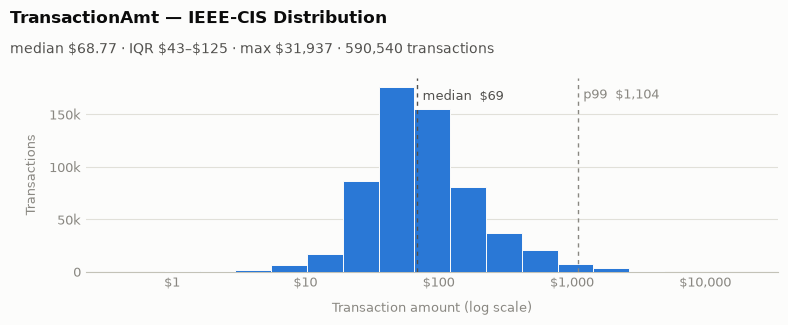

In [27]:
import numpy as np

plt.rcParams['text.parse_math'] = False   # keep '$' literal instead of mathtext

amt = train['TransactionAmt']
q = amt.quantile([0.25, 0.5, 0.75, 0.99])

# amounts span $0.25 -> $32k with 75% of the mass under $125, so bin on a log scale
bins = np.logspace(np.log10(amt.min()), np.log10(amt.max()), 20)

fig, ax = plt.subplots(figsize=(8, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.hist(amt, bins=bins, color=BLUE, ec=SURFACE, lw=0.7, zorder=3)
ax.set_xscale('log')

for x, lab, col in [(q[0.5], f'median  ${q[0.5]:,.0f}', INK2),
                    (q[0.99], f'p99  ${q[0.99]:,.0f}', MUTED)]:
    ax.axvline(x, color=col, lw=1, ls=(0, (3, 3)), zorder=4)
    ax.annotate(lab, xy=(x, 1), xycoords=('data', 'axes fraction'),
                xytext=(4, -8), textcoords='offset points',
                fontsize=9, color=col, ha='left', va='top')

ax.set_xlim(amt.min() * 0.9, amt.max() * 1.1)
ax.xaxis.set_major_formatter(lambda v, _: f'${v:,.0f}')
ax.xaxis.set_minor_formatter(lambda v, _: '')
ax.yaxis.set_major_formatter(lambda v, _: f'{v / 1000:,.0f}k' if v else '0')
ax.tick_params(axis='both', which='both', labelsize=9.5, colors=MUTED, length=0)
ax.grid(axis='y', color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ('top', 'right', 'left'):
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color(AXIS)
ax.set_xlabel('Transaction amount (log scale)', fontsize=9.5, color=MUTED, labelpad=8)
ax.set_ylabel('Transactions', fontsize=9.5, color=MUTED, labelpad=8)

fig.subplots_adjust(left=0.115, right=0.98, top=0.76, bottom=0.19)
fig.text(0.02, 0.96, 'TransactionAmt — IEEE-CIS Distribution',
         fontsize=12.5, color=INK, va='top', weight='bold')
fig.text(0.02, 0.865, f'median ${q[0.5]:,.2f} · IQR ${q[0.25]:,.0f}–${q[0.75]:,.0f} · '
                      f'max ${amt.max():,.0f} · {len(amt):,} transactions',
         fontsize=10, color=INK2, va='top')
plt.show()

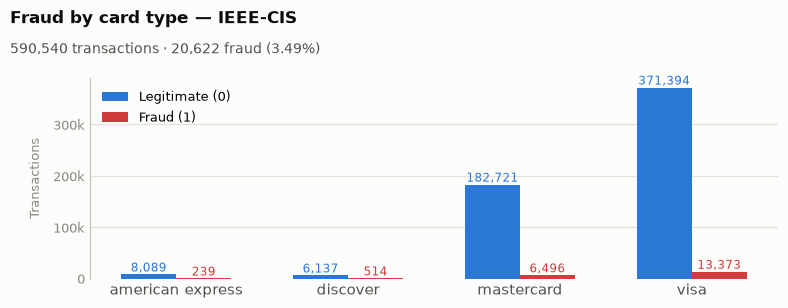

In [30]:
# card4 grouped bar: fraud vs not-fraud per card type

ct = pd.crosstab(train['card4'], train['isFraud'])
ct.columns = ['Legitimate (0)', 'Fraud (1)']

fig, ax = plt.subplots(figsize=(8, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

x = np.arange(len(ct))
w = 0.32

bars0 = ax.bar(x - w / 2, ct['Legitimate (0)'], w, label='Legitimate (0)', color=BLUE, zorder=3)
bars1 = ax.bar(x + w / 2, ct['Fraud (1)'], w, label='Fraud (1)', color=RED, zorder=3)

for bar in bars0:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8.5, color=BLUE)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=8.5, color=RED)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=10.5, color=INK2)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', labelsize=9.5, colors=MUTED, length=0)
ax.yaxis.set_major_formatter(lambda v, _: f'{v / 1000:,.0f}k' if v else '0')
ax.grid(axis='y', color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
ax.spines['left'].set_color(AXIS)
ax.set_ylabel('Transactions', fontsize=9.5, color=MUTED, labelpad=8)

legend = ax.legend(fontsize=9.5, framealpha=0, loc='upper left')

fig.subplots_adjust(left=0.12, right=0.98, top=0.76, bottom=0.17)
fig.text(0.02, 0.96, 'Fraud by card type — IEEE-CIS',
         fontsize=12.5, color=INK, va='top', weight='bold')
fig.text(0.02, 0.865,
         f'{len(train):,} transactions · '
         f'{ct["Fraud (1)"].sum():,} fraud '
         f'({ct["Fraud (1)"].sum() / len(train) * 100:.2f}%)',
         fontsize=10, color=INK2, va='top')
plt.show()

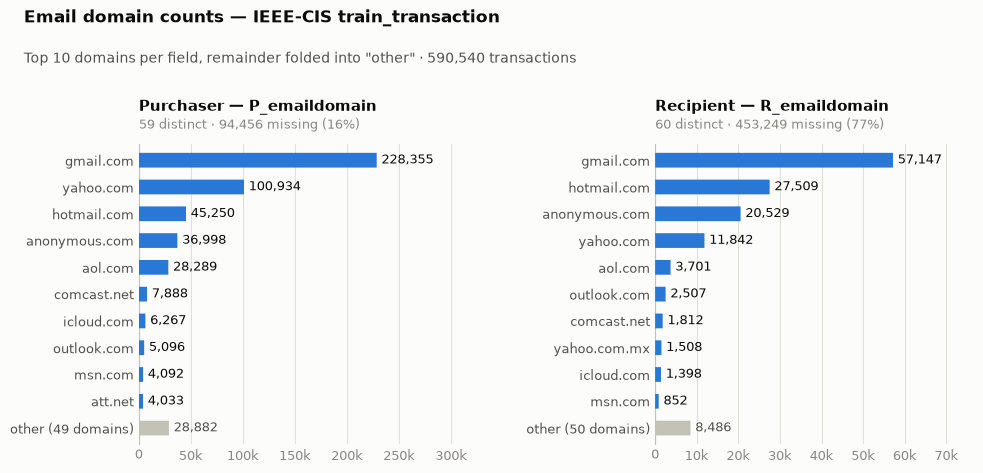

In [17]:
TOP = 10
COLS = [('P_emaildomain', 'Purchaser'), ('R_emaildomain', 'Recipient')]

fig, axes = plt.subplots(1, 2, figsize=(10, 5.0), facecolor=SURFACE)

for ax, (col, label) in zip(axes, COLS):
    vc = train[col].value_counts()
    rest = vc.iloc[TOP:]
    s = pd.concat([vc.head(TOP), pd.Series({f'other ({len(rest)} domains)': rest.sum()})])
    n_missing = train[col].isna().sum()

    ax.set_facecolor(SURFACE)
    for i, (name, c) in enumerate(s.items()):
        is_other = name.startswith('other')
        rbar(ax, i, c, 0.55, AXIS if is_other else BLUE)   # aggregate bar reads as neutral
        ax.text(c + s.max() * 0.02, i, f'{c:,}', va='center', ha='left',
                fontsize=9, color=INK2 if is_other else INK)

    ax.set_yticks(range(len(s)), s.index, fontsize=9.5, color=INK2)
    ax.invert_yaxis()
    ax.set_xlim(0, s.max() * 1.34)
    ax.set_ylim(len(s) - 0.4, -0.6)
    ax.xaxis.set_major_formatter(lambda v, _: f'{v / 1000:,.0f}k' if v else '0')
    ax.tick_params(axis='x', labelsize=9, colors=MUTED, length=0)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for sp in ('top', 'right', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(AXIS)
    ax.set_title(f'{label} — {col}', fontsize=10.5, color=INK, loc='left',
                 pad=24, weight='bold')
    ax.annotate(f'{train[col].nunique()} distinct · {n_missing:,} missing '
                f'({n_missing / len(train) * 100:.0f}%)',
                xy=(0, 1), xycoords='axes fraction', xytext=(0, 9),
                textcoords='offset points', fontsize=9, color=MUTED, va='bottom')

fig.subplots_adjust(left=0.135, right=0.97, top=0.70, bottom=0.10, wspace=0.62)
fig.text(0.02, 0.97, 'Email domain counts — IEEE-CIS train_transaction',
         fontsize=12.5, color=INK, va='top', weight='bold')
fig.text(0.02, 0.885, f'Top {TOP} domains per field, remainder folded into "other" · '
                      f'{len(train):,} transactions',
         fontsize=10, color=INK2, va='top')
plt.show()